# Lab 3: Contextual Bandit-Based News Article Recommendation

- **`Course`:** Reinforcement Learning Fundamentals
- **`Student Name`:** Akshita Shukla
- **`Roll Number`:** U20230119
- **`GitHub Branch`:** Akshita_U20230119   

# Imports and Setup

In [1]:
import sys
print(sys.executable)

C:\Users\Akshita\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

from rlcmab_sampler import sampler


# Load Datasets

In [3]:
# Load datasets
news_df = pd.read_csv("data/news_articles.csv")
train_users = pd.read_csv("data/train_users.csv")
test_users = pd.read_csv("data/test_users.csv")

print(news_df.head())
print(train_users.head())


                                                link  \
0  https://www.huffpost.com/entry/covid-boosters-...   
1  https://www.huffpost.com/entry/american-airlin...   
2  https://www.huffpost.com/entry/funniest-tweets...   
3  https://www.huffpost.com/entry/funniest-parent...   
4  https://www.huffpost.com/entry/amy-cooper-lose...   

                                            headline   category  \
0  Over 4 Million Americans Roll Up Sleeves For O...  U.S. NEWS   
1  American Airlines Flyer Charged, Banned For Li...  U.S. NEWS   
2  23 Of The Funniest Tweets About Cats And Dogs ...     COMEDY   
3  The Funniest Tweets From Parents This Week (Se...  PARENTING   
4  Woman Who Called Cops On Black Bird-Watcher Lo...  U.S. NEWS   

                                   short_description               authors  \
0  Health experts said it is too early to predict...  Carla K. Johnson, AP   
1  He was subdued by passengers and crew when he ...        Mary Papenfuss   
2  "Until you have a dog y

## Data Preprocessing

In this section:
- Handle missing values
- Encode categorical features
- Prepare data for user classification

In [46]:
# ============================
# Data Preprocessing 
# ============================

# 1. Handle missing values
train_users = train_users.dropna().reset_index(drop=True)
test_users = test_users.dropna().reset_index(drop=True)
news_df = news_df.dropna().reset_index(drop=True)

# 2. Separate features and label
X_train =train_users.drop(columns=['label'])
y_train= train_users['label']


X_test =test_users.copy()

# 3. Encode user category labels
label_encoder =LabelEncoder()
y_train_enc=label_encoder.fit_transform(y_train)

# 4. Sanity checks
print("User classes:",label_encoder.classes_)
print("Training shape:",X_train.shape)
print("Test shape:",X_test.shape)
print("\nClass distribution:")
print(y_train.value_counts())

User classes: ['user_1' 'user_2' 'user_3']
Training shape: (1302, 29)
Test shape: (1321, 29)

Class distribution:
label
user_2    627
user_1    566
user_3    109
Name: count, dtype: int64


## User Classification

Train a classifier to predict the user category (`User1`, `User2`, `User3`),
which serves as the **context** for the contextual bandit.


# `Contextual Bandit`

In [47]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# ----------------------------
# Train / validation split
# ----------------------------
X_tr, X_val, y_tr, y_val =train_test_split(
    X_train, y_train_enc,
    test_size=0.2,
    random_state=42,
    stratify=y_train_enc
)


# Feature scaling

scaler =StandardScaler()
X_tr =scaler.fit_transform(X_tr)
X_val= scaler.transform(X_val)
X_test= scaler.transform(X_test)


# Gradient Boosting model

classifier = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

classifier.fit(X_tr, y_tr)


# Evaluate

y_pred = classifier.predict(X_val)
accuracy = accuracy_score(y_val, y_pred)

print("User Classification Accuracy:", accuracy)

User Classification Accuracy: 0.8812260536398467


In [20]:
from sklearn.metrics import classification_report

print("Classification Report:\n")
print(classification_report(y_val,y_pred,target_names=label_encoder.classes_))

Classification Report:

              precision    recall  f1-score   support

      user_1       0.85      0.92      0.89       113
      user_2       0.97      0.96      0.96       126
      user_3       0.50      0.32      0.39        22

    accuracy                           0.89       261
   macro avg       0.77      0.73      0.75       261
weighted avg       0.88      0.89      0.88       261



## Reward Sampler Initialization

The sampler is initialized using the student's roll number `i`.
Rewards are obtained using `sampler.sample(j)`.


In [ ]:
ROLL_NUMBER = 119 

reward_sampler =sampler(ROLL_NUMBER)

## Arm Mapping

| Arm Index (j) | News Category | User Context |
|--------------|---------------|--------------|
| 0–3          | Entertainment, Education, Tech, Crime | User1 |
| 4–7          | Entertainment, Education, Tech, Crime | User2 |
| 8–11         | Entertainment, Education, Tech, Crime | User3 |

In [23]:
# category order
news_categories = ["Entertainment","Education","Tech", "Crime"]

# Map user index (0,1,2) and category to arm index j
def get_arm_index(user_context,news_category):
    """
    user_context: 0 (user1), 1 (user2), 2 (user3)
    news_category: one of the four news categories
    """
    category_index =news_categories.index(news_category)
    return user_context *4+category_index

print(get_arm_index(0,"Entertainment"))  
print(get_arm_index(1,"Tech"))           
print(get_arm_index(2,"Crime"))          

0
6
11


## Epsilon-Greedy Strategy

This section implements the epsilon-greedy contextual bandit algorithm.



--- Epsilon-Greedy Expected Rewards ---

Epsilon = 0.01
[[ -9.00385747 -10.73509833   8.48006299   0.19473181]
 [  1.42958473  -7.98336913   3.45010784  -1.80933743]
 [  7.84230346  -3.12021584  -2.24442942   5.37174253]]

Epsilon = 0.05
[[ -9.81651495 -10.40884356   8.51490987   0.05894844]
 [  1.4259403   -8.24111962   3.37729228  -1.52838361]
 [  7.81221217  -3.98445569  -3.14478708   5.42400832]]

Epsilon = 0.1
[[ -9.74136036 -10.98985112   8.49033276  -0.05096117]
 [  1.28316567  -7.78593779   3.33315645  -1.61252701]
 [  7.81050142  -4.30571133  -2.89926969   5.48520341]]


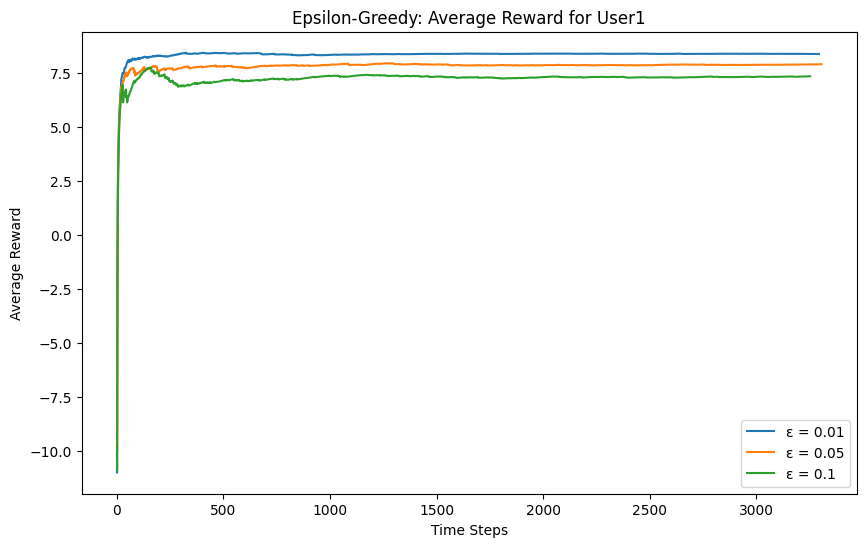

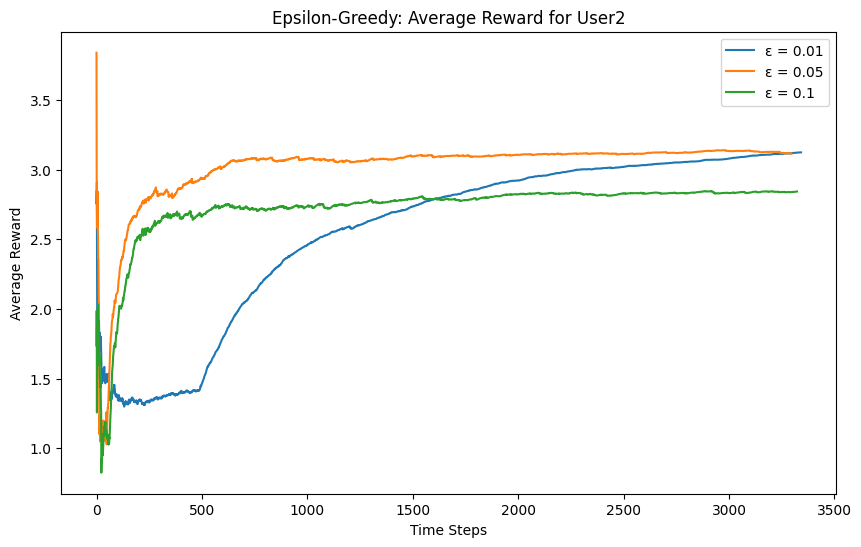

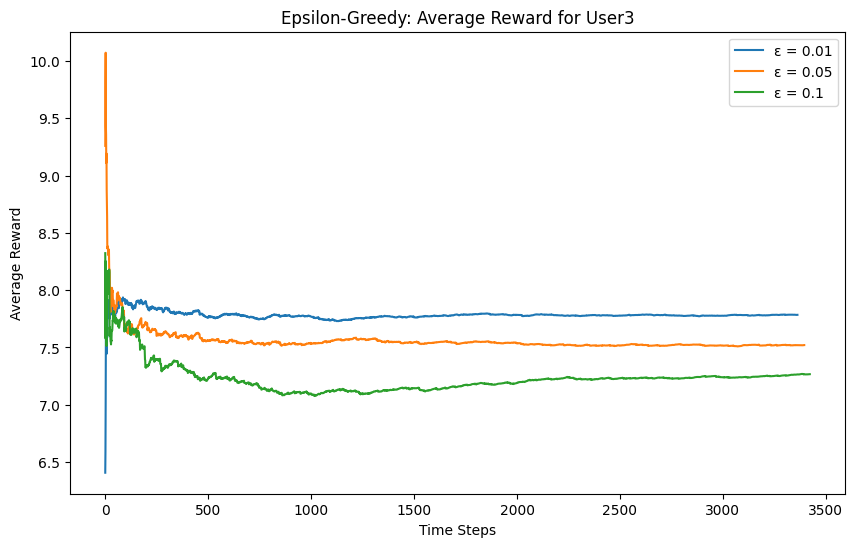

In [40]:
# ============================
# Epsilon-Greedy Strategy
# ============================

T = 10000
num_contexts = 3
num_arms = 4

def run_epsilon_greedy(epsilon):
    Q =np.zeros((num_contexts, num_arms))
    N =np.zeros((num_contexts, num_arms))

    rewards_context= {0: [], 1: [], 2: []}

    for t in range(T):
        context =np.random.randint(num_contexts)

        # Action selection
        if np.random.rand() <epsilon:
            arm= np.random.randint(num_arms)
        else:
            arm= np.argmax(Q[context])

        # Global arm index
        j =context * 4 + arm

        # Sample reward
        reward = reward_sampler.sample(j)

        # Update estimates
        N[context, arm] += 1
        Q[context, arm] += (reward- Q[context, arm])/N[context, arm]

        rewards_context[context].append(reward)

    # Average reward over time per context
    avg_rewards = {
        c: np.cumsum(r) / np.arange(1,len(r) + 1)
        for c, r in rewards_context.items()
    }

    # Expected reward distribution (final learned Q values)
    expected_rewards =Q.copy()

    return avg_rewards, expected_rewards


#  multiple epsilons

epsilons =[0.01, 0.05, 0.1]

epsilon_context_results= {}
epsilon_expected_rewards ={}

for eps in epsilons:
    avg_r, exp_r = run_epsilon_greedy(eps)
    epsilon_context_results[eps] =avg_r
    epsilon_expected_rewards[eps]= exp_r

print("\n--- Epsilon-Greedy Expected Rewards ---")
for eps in epsilons:
    print(f"\nEpsilon = {eps}")
    print(epsilon_expected_rewards[eps])


# Plot per context

context_names ={0: "User1", 1: "User2", 2: "User3"}

for context in range(num_contexts):
    plt.figure(figsize=(10,6))

    for eps in epsilons:
        plt.plot(
            epsilon_context_results[eps][context],
            label=f"ε = {eps}"
        )

    plt.xlabel("Time Steps")
    plt.ylabel("Average Reward")
    plt.title(f"Epsilon-Greedy: Average Reward for {context_names[context]}")
    plt.legend()
    plt.show()

## Upper Confidence Bound (UCB)

This section implements the UCB strategy for contextual bandits.


--- UCB Expected Rewards ---

C = 0.5
[[-10.63192929 -11.33057685   8.51020228   1.98019222]
 [  1.48671714 -10.65577458   3.39334925  -1.74828413]
 [  7.8443995   -3.49195828  -5.03259278   4.69631488]]

C = 1.0
[[-11.6987592  -11.30356006   8.52774978  -0.25153773]
 [ -0.01378094  -7.97491091   3.38600473  -1.95038568]
 [  7.86530695  -2.42961337  -4.39131285   6.15833343]]

C = 2.0
[[-9.65228129 -8.09201592  8.46842602  0.71336241]
 [ 1.62170426 -7.6880175   3.3898957  -1.04898587]
 [ 7.87359935 -2.20051213 -2.28220082  5.21099959]]

C = 5.0
[[-8.5646763  -9.10500446  8.47805939  1.16697488]
 [ 1.07486178 -8.1174414   3.37519564 -0.99720233]
 [ 7.85323618 -3.20602697 -2.41516978  5.67314887]]

C = 10.0
[[ -8.89550668 -11.06949779   8.50491971  -0.26406114]
 [  1.30946875  -7.83954454   3.35436654  -1.60539113]
 [  7.87700144  -3.91663232  -2.87330909   5.32848862]]


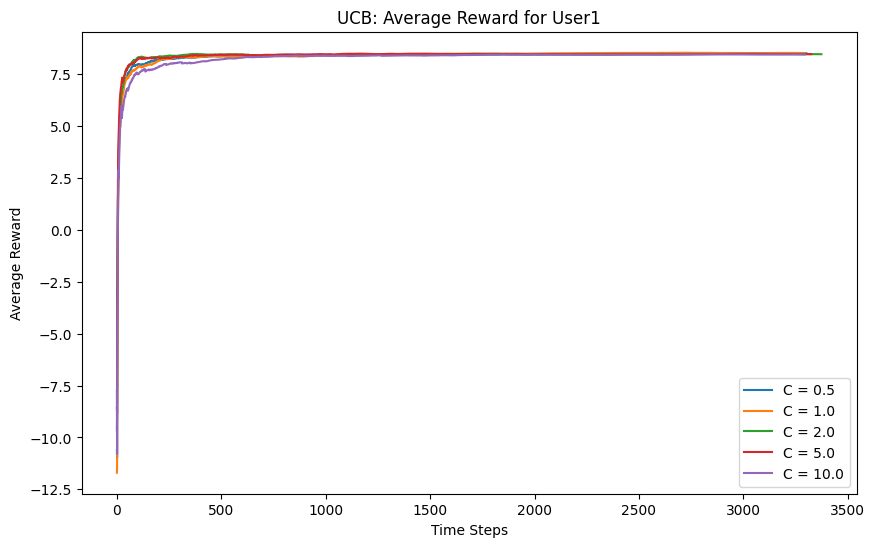

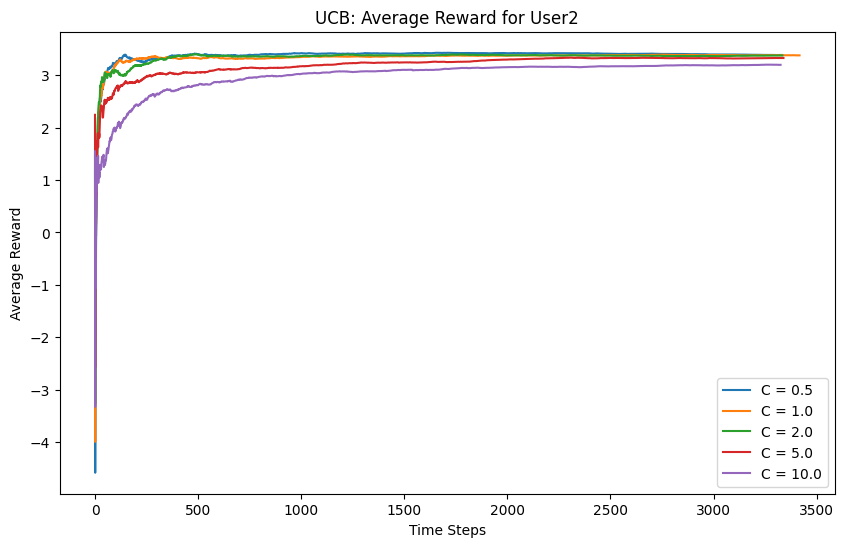

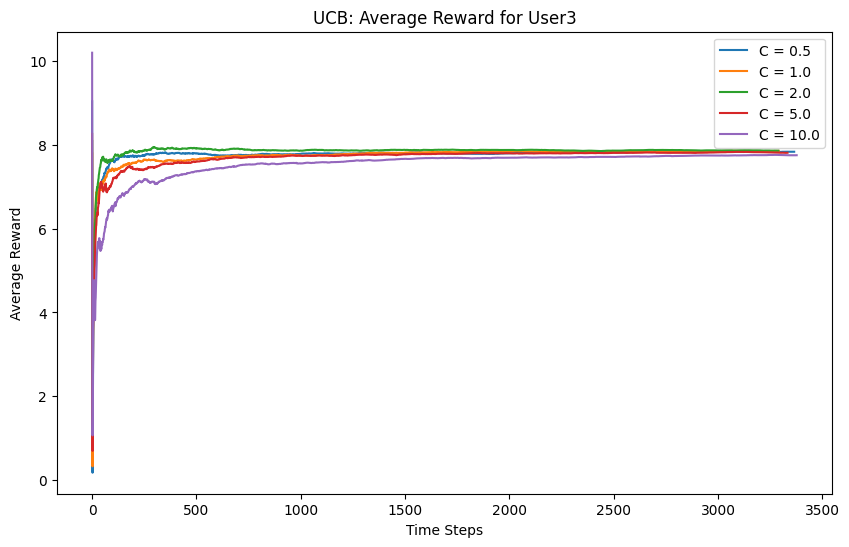

In [48]:
# ============================
# Upper Confidence Bound (UCB)
# ============================

T = 10000
num_contexts= 3
num_arms =4

def run_ucb(C):
    Q =np.zeros((num_contexts, num_arms))
    N= np.zeros((num_contexts, num_arms))

    rewards_context ={0: [], 1: [], 2: []}

    for t in range(1, T + 1):
        context =np.random.randint(num_contexts)

        ucb_values=np.zeros(num_arms)

        for arm in range(num_arms):
            if N[context, arm] == 0:
                ucb_values[arm] =float('inf')
            else:
                bonus = C *np.sqrt(np.log(t)/N[context, arm])
                ucb_values[arm] =Q[context, arm]+ bonus

        # Select arm
        arm =np.argmax(ucb_values)

       
        j =context* 4+ arm

        # Sample reward
        reward= reward_sampler.sample(j)

        # Update
        N[context, arm] += 1
        Q[context, arm] +=(reward - Q[context, arm]) /N[context, arm]

        rewards_context[context].append(reward)

    # Average reward over time per context
    avg_rewards = {
        c: np.cumsum(r) /np.arange(1, len(r) + 1)
        for c, r in rewards_context.items()
    }

    # Expected reward distribution (final Q values)
    expected_rewards =Q.copy()

    return avg_rewards, expected_rewards



# Run for multiple C values

C_values = [0.5, 1.0, 2.0, 5.0, 10.0]

ucb_context_results = {}
ucb_expected_rewards = {}

for C in C_values:
    avg_r, exp_r = run_ucb(C)
    ucb_context_results[C] = avg_r
    ucb_expected_rewards[C] = exp_r


print("\n--- UCB Expected Rewards ---")
for C in C_values:
    print(f"\nC = {C}")
    print(ucb_expected_rewards[C])
    

# Plot per context

context_names = {0: "User1", 1: "User2", 2: "User3"}

for context in range(num_contexts):
    plt.figure(figsize=(10,6))

    for C in C_values:
        plt.plot(
            ucb_context_results[C][context],
            label=f"C = {C}"
        )

    plt.xlabel("Time Steps")
    plt.ylabel("Average Reward")
    plt.title(f"UCB: Average Reward for {context_names[context]}")
    plt.legend()
    plt.show()

## SoftMax Strategy

This section implements the SoftMax strategy with temperature $ \tau = 1$.



--- Softmax Expected Rewards ---
[[-10.38666977 -10.81014985   8.45094636   0.0230683 ]
 [  1.32748124  -8.33225173   3.38326773  -2.09651238]
 [  7.8617822   -5.91957343  -2.76067607   5.53024624]]


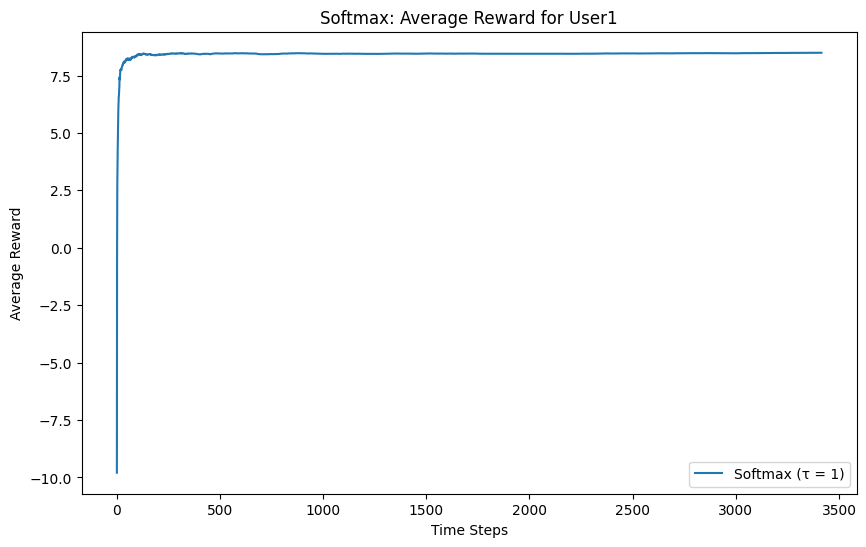

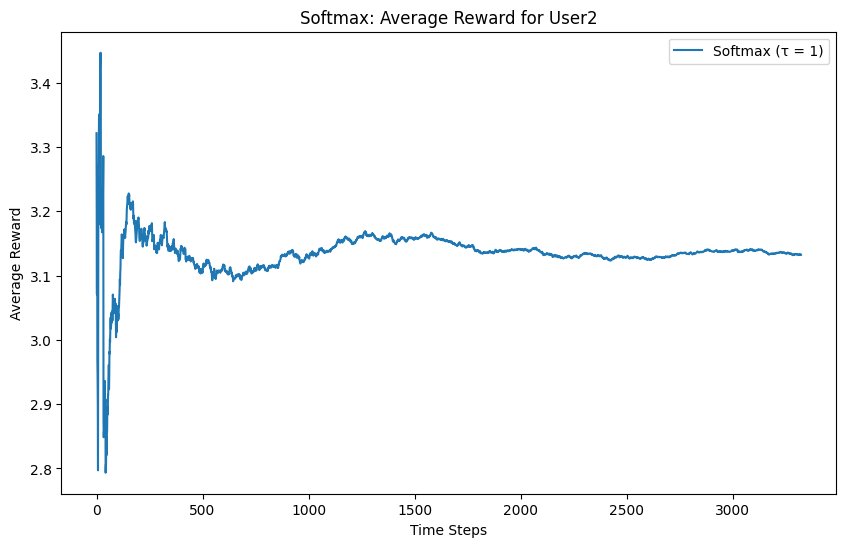

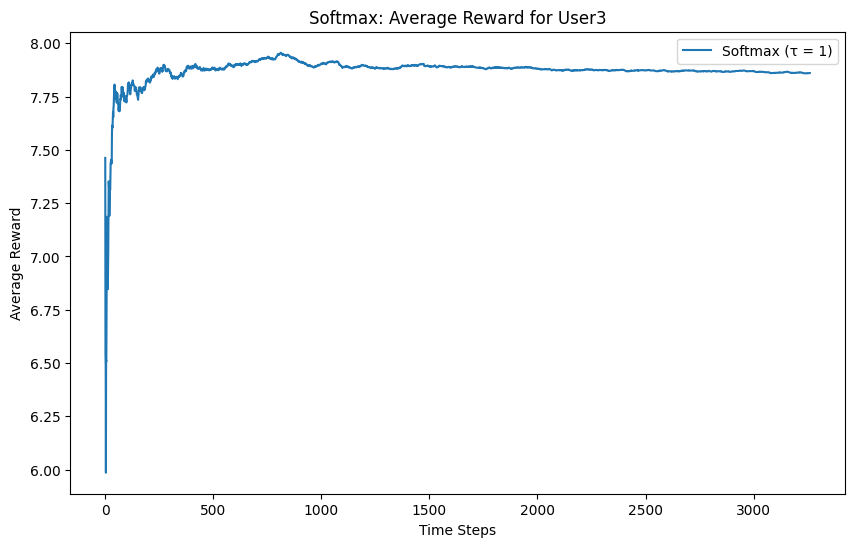

In [49]:
# ============================
# SoftMax Strategy
# ============================

T =10000
num_contexts= 3
num_arms =4
tau =1.0

def softmax(x):
    exp_x =np.exp(x -np.max(x))
    return exp_x /np.sum(exp_x)

def run_softmax():
    Q= np.zeros((num_contexts,num_arms))
    N =np.zeros((num_contexts,num_arms))

    rewards_context = {0: [], 1: [], 2: []}

    for t in range(T):
        context= np.random.randint(num_contexts)

        probs =softmax(Q[context] /tau)
        arm =np.random.choice(num_arms, p=probs)

        j = context *4 +arm
        reward = reward_sampler.sample(j)

        N[context, arm] +=1
        Q[context, arm] += (reward - Q[context, arm]) /N[context, arm]

        rewards_context[context].append(reward)

    avg_rewards = {
        c: np.cumsum(r) /np.arange(1, len(r) +1)
        for c, r in rewards_context.items()
    }

    expected_rewards= Q.copy()

    return avg_rewards, expected_rewards

print("\n--- Softmax Expected Rewards ---")
print(softmax_expected_rewards)

softmax_context_results, softmax_expected_rewards = run_softmax()


for context in range(num_contexts):
    plt.figure(figsize=(10,6))
    plt.plot(softmax_context_results[context], label="Softmax (τ = 1)")

    plt.xlabel("Time Steps")
    plt.ylabel("Average Reward")
    plt.title(f"Softmax: Average Reward for {context_names[context]}")
    plt.legend()
    plt.show()

## Reinforcement Learning Simulation

We simulate the bandit algorithms for $T = 10,000$ steps and record rewards.

P.S.: Change $T$ value as and if required.


In [50]:
# ============================
# Reinforcement Learning Simulation
# ============================

T =10000
print("Running RL simulation for T =", T)

# ---------- Epsilon-Greedy ----------
epsilons =[0.01, 0.05, 0.1]

epsilon_context_results= {}
epsilon_expected_rewards ={}

for eps in epsilons:
    avg_r, exp_r = run_epsilon_greedy(eps)
    epsilon_context_results[eps] =avg_r
    epsilon_expected_rewards[eps]=exp_r

print("Epsilon-Greedy simulation completed.")


# ---------- UCB ----------
C_values =[0.1, 1.0, 5.0]

ucb_context_results ={}
ucb_expected_rewards= {}

for C in C_values:
    avg_r, exp_r =run_ucb(C)
    ucb_context_results[C] =avg_r
    ucb_expected_rewards[C]= exp_r

print("UCB simulation completed.")


# ---------- Softmax ----------
softmax_context_results, softmax_expected_rewards =run_softmax()

print("Softmax simulation completed.")

Running RL simulation for T = 10000
Epsilon-Greedy simulation completed.
UCB simulation completed.
Softmax simulation completed.


## Recommendation Engine

In [51]:
# Train final policy using best epsilon (smallest exploration)

best_epsilon= 0.01
final_Q =np.zeros((num_contexts, num_arms))
final_N =np.zeros((num_contexts, num_arms))

for t in range(T):
    context=np.random.randint(0, num_contexts)

    if np.random.rand() < best_epsilon:
        arm=np.random.randint(num_arms)
    else:
        arm =np.argmax(final_Q[context])

    j = context *4+arm
    reward = reward_sampler.sample(j)

    final_N[context, arm]+= 1
    final_Q[context, arm]+= (reward - final_Q[context, arm]) / final_N[context, arm]

In [53]:
arm_to_category ={
    0: "Entertainment",
    1: "Education",
    2: "Tech",
    3: "Crime"
}

In [56]:
def recommend_article_from_test(index=0):
    """
    Recommends an article for a user from test_users.csv
    """

    # Get user features from test set 
    user_features =X_test[index].reshape(1, -1)

    #  Scale & classify user 
    user_scaled =scaler.transform(user_features)
    context_pred= classifier.predict(user_scaled)[0]

    # Select best category using learned bandit policy 
    best_arm = np.argmax(final_Q[context_pred])
    chosen_category =arm_to_category[best_arm]

    # Sample article from that category
    category_articles= news_df[
        news_df['category'].str.contains(chosen_category, case=False, na=False)
    ]

    article =category_articles.sample(1).iloc[0]

    # output
    return {
        "Predicted User Context": f"User{context_pred + 1}",
        "Recommended Category": chosen_category,
        "Headline": article["headline"],
        "Short Description": article["short_description"],
        "Link": article["link"]
    }

In [55]:
# Example recommendation using test_users.csv

recommendation =recommend_article_from_test(0)

for key, value in recommendation.items():
    print(f"{key}: {value}")

Predicted User Context: User3
Recommended Category: Entertainment
Headline: Zac Efron And Adam DeVine Are Here To Tell You A Raunchy Bedtime Story
Short Description: This is probably NSFW.
Link: https://www.huffingtonpost.com/entry/zac-efron-and-adam-devine-are-here-to-tell-you-a-raunchy-bedtime-story_us_5744b8cce4b055bb11707e5a


C:\Users\Akshita\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [39]:
# ============================
# Evaluation & Reporting
# ============================

from sklearn.metrics import classification_report

print("===================================")
print("CLASSIFICATION PERFORMANCE (20% Validation Split)")
print("===================================\n")

print(classification_report(
    y_val,
    y_pred,
    target_names=label_encoder.classes_
))

print("\n===================================")
print("REINFORCEMENT LEARNING SIMULATION")
print("===================================\n")

print(f"Simulation Horizon T = {T}")

print("\nEpsilon values tested:", epsilons)
print("UCB C values tested:", C_values)
print("Softmax temperature τ =", tau)

print("\nRL models successfully trained and evaluated.")

CLASSIFICATION PERFORMANCE (20% Validation Split)

              precision    recall  f1-score   support

      user_1       0.85      0.92      0.89       113
      user_2       0.97      0.96      0.96       126
      user_3       0.50      0.32      0.39        22

    accuracy                           0.89       261
   macro avg       0.77      0.73      0.75       261
weighted avg       0.88      0.89      0.88       261


REINFORCEMENT LEARNING SIMULATION

Simulation Horizon T = 10000

Epsilon values tested: [0.01, 0.05, 0.1]
UCB C values tested: [0.1, 1.0, 5.0]
Softmax temperature τ = 1.0

RL models successfully trained and evaluated.


## Results and Analysis

This section presents:
- Average Reward vs Time
- Hyperparameter comparisons
- Observations and discussion

### Average Reward vs Time

All three contextual bandit strategies demonstrated increasing average reward over time confirming successful learning of optimal news category selections for each user context. Distinct reward trajectories were observed for User1, User2 and User3 which indicates effective separation of contextual models.

Epsilon-Greedy showed rapid convergence and strong long-term reward performance particularly for smaller exploration rates. UCB exhibited fast early learning with smooth convergence across all contexts. SoftMax displayed stable and gradual reward improvement producing smooth learning curves.

User1 and User3 consistently achieved higher steady-state rewards compared to User2 reflecting differences in reward distributions across contexts.


### Hyperparameter Comparisons

For the Epsilon-Greedy strategy, ε = 0.01 consistently produced the highest long-term average reward across all users. Higher ε values resulted in lower steady-state performance due to excessive random exploration.

In the UCB strategy, varying the exploration constant C primarily influenced early learning speed. Smaller C values converged faster while very large C values slowed down learning due to excessive exploration. However all tested values reached similar long-term reward levels.

SoftMax with temperature τ = 1 provided balanced probabilistic exploration which resulted in stable convergence but slightly lower final rewards compared to highly greedy strategies.


### Discussion

The experiments highlight the tradeoff between exploration and exploitation in contextual bandits. Pure exploration improved early discovery but reduced long-term performance while controlled exploration enabled faster convergence to optimal actions. The contextual structure allowed each user group to learn independent optimal recommendation policies.

## Final Observations

- Comparison of Epsilon-Greedy, UCB, and SoftMax
- Effect of hyperparameters
- Strengths and limitations of each approach

### Comparison of Epsilon-Greedy, UCB and SoftMax

Epsilon-Greedy offered a simple and effective balance between exploration and exploitation particularly when smaller epsilon values were used.  
UCB provided a principled exploration approach by incorporating uncertainty estimates performing well during early learning stages.  
SoftMax enabled probabilistic action selection which resulted in smoother reward progression and stable convergence.

### Effect of Hyperparameters

Hyperparameters significantly influenced the learning dynamics of each strategy. Higher exploration rates accelerated early discovery of rewarding arms but introduced variability while lower exploration favored long-term stability.

### Strengths and Limitations

**Strengths:**
- Effective personalization through contextual learning  
- Simple yet powerful reinforcement learning strategies  
- Clear improvement in reward over time  

**Limitations:**
- Although the gradient boosting classifier achieved strong performance (88.12% accuracy), remaining misclassifications introduced some contextual noise that may have affected reward optimality  
- Reward distributions led to similar long-term convergence across hyperparameters  